# Partie C: Classification

- **Dataset**: Pima Indians Diabetes
- **Objectif**: Prédire la présence de diabète (étiquette binaire).

In [19]:
# Importation des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Chargement:

Chargement de `diabetes.csv`

In [3]:
# Chargement du Dataset
dataset=pd.read_csv('../dataset/diabetes.csv')
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 2. Nettoyage et prétraitement:

In [4]:
# Nettoyage et Pretraitement
# TODO:
# Pregnancies
# Glucose
# BloodPressure
# SkinThickness
# Insulin
# BMI
# DiabetesPedigreeFunction
# Age
# Outcome

# 3. EDA et déséquilibre

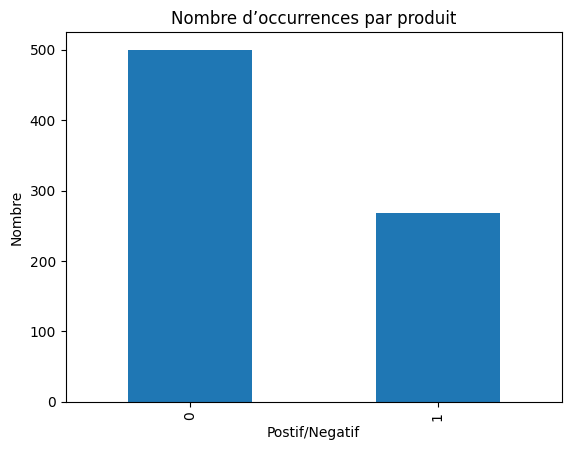

In [5]:
# Barplots du Nombre Positifs/Negatifs
count_pos_neg= dataset['Outcome'].value_counts()

count_pos_neg.plot(kind='bar')
plt.title('Nombre d’occurrences par produit')
plt.xlabel('Postif/Negatif')
plt.ylabel('Nombre')
plt.show()

In [ ]:
# Statistiques Descriptives Par Classes
# TODO


# 4. Split train/validation/test

In [7]:
# Creation des Variables X et Y
## X => Pregnancies,Glucose ,BloodPressure ,SkinThickness 
#      ,Insulin ,BMI ,DiabetesPedigreeFunction,Age ,Outcome

X=dataset.drop('Outcome', axis=1)

## Y => Outcome,
Y=dataset['Outcome']

In [8]:
## Spilter en 60% train, 20% validation et 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X,Y, test_size=0.4, random_state=0)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

# 5. Feature engineering / sélection:

In [10]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Conversion en Dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X.columns)
X_val_scaled_df   = pd.DataFrame(X_val_scaled,columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,columns=X.columns)

# Test d'affichage
X_train_scaled_df.head()
X_val_scaled_df.head()
X_test_scaled_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.124862,0.481731,-3.765914,-1.359726,-0.739048,0.508058,1.356072,-0.709927
1,1.835302,0.512513,0.509837,-1.359726,-0.739048,-0.653720,2.850328,1.994558
2,0.355220,0.635639,0.402943,-1.359726,-0.739048,1.606696,-0.829425,1.149406
3,-0.828846,0.635639,0.189156,0.059167,-0.242907,-0.767372,-0.635289,-1.047988
4,-0.532830,0.666420,-0.665995,0.768614,0.358968,-0.085459,-0.147009,-0.709927


# 6. Gestion du désequilibre:

In [ ]:
# Gestion du Desequilibre
desequiblre='balanced' # Mettre le class weight en balanced

# 7. Modelisation initiale

In [14]:
# Logistic Regression
model = LogisticRegression(class_weight=desequiblre, random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
# Prediction sur le Set de Validation
y_val_pred = model.predict(X_val_scaled)

In [18]:
# Rapport de Evaluation Accuracy, Precision, Recall, F1
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, average='binary')
recall = recall_score(y_val, y_val_pred, average='binary')
f1 = f1_score(y_val, y_val_pred, average='binary')

# Affichage
print("Évaluation sur le set validation :")
print(f"Accuracy  : {accuracy:.8f}")
print(f"Precision : {precision:.8f}")
print(f"Recall    : {recall:.8f}")
print(f"F1 Score  : {f1:.8f}")

Évaluation sur le set validation :
Accuracy  : 0.70779221
Precision : 0.57894737
Recall    : 0.61111111
F1 Score  : 0.59459459


# 8. Evaluation finale

In [20]:
# Matrice de Confusion et analyse sur le set de test

# Prediction sur le set test
y_test_pred = model.predict(X_test_scaled)

# Evaluation
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='binary')
recall_test = recall_score(y_test, y_test_pred, average='binary')
f1_test = f1_score(y_test, y_test_pred, average='binary')

# Affichage des Evaluations
print("Évaluation finale sur Test Set:")
print(f"Accuracy  : {accuracy_test:.8f}")
print(f"Precision : {precision_test:.8f}")
print(f"Recall    : {recall_test:.8f}")
print(f"F1 Score  : {f1_test:.8f}")

Évaluation finale sur Test Set:
Accuracy  : 0.80519481
Precision : 0.66101695
Recall    : 0.79591837
F1 Score  : 0.72222222


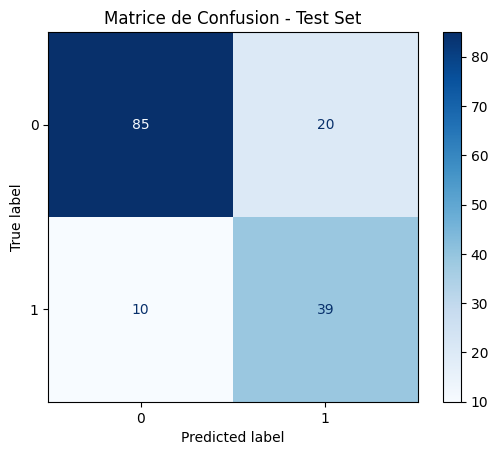

In [21]:
# Matrice de Confusions
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de Confusion - Test Set")
plt.show()